In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Read data and sort it
with open("20260512.30_minuten_mcs.ws5", "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

data_lines = [line.strip() for line in lines[4:-4]]
y_values = np.array([float(x) for x in data_lines])
y_values = y_values / np.max(y_values)
x_values = np.arange(len(y_values))

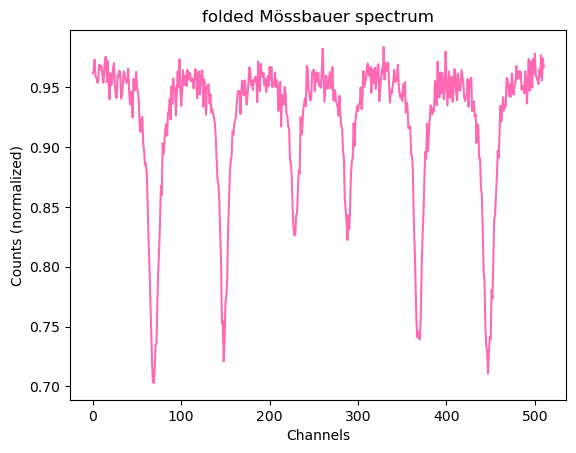

In [3]:
#half the data and fold it
laenge = len(y_values)
y_left = y_values[:laenge//2]
y_right = y_values[laenge//2:-1]

y_mirror_right = y_right[::-1]
y_short = (y_left + y_mirror_right) / 2
x_half = x_values[:laenge//2]

plt.plot(x_half, y_short, color='hotpink')
plt.xlabel('Channels')
plt.ylabel('Counts (normalized)')
plt.title('folded Mössbauer spectrum')
plt.show()

In [4]:
# search 6 peaks
search_areas = [(50, 100), (100, 200), (200, 250), (250, 300), (350, 400), (400, 500)]
peak_channels = []

print("found Minima (nummer of channels):")
for min_val, max_val in search_areas:
    mask = (x_half > min_val) & (x_half < max_val)
    idx = np.argmin(y_short[mask])
    channel = x_half[mask][idx]
    peak_channels.append(channel)
    print(f"area {min_val}-{max_val}: channel {peak_channels}")

found Minima (nummer of channels):
area 50-100: channel [69]
area 100-200: channel [69, 148]
area 200-250: channel [69, 148, 228]
area 250-300: channel [69, 148, 228, 288]
area 350-400: channel [69, 148, 228, 288, 370]
area 400-500: channel [69, 148, 228, 288, 370, 447]


In [5]:
# calibaration of the velocity axis (x-axis)
velocity_raw = np.arange(len(y_short))
velocity = 0.02793 * (velocity_raw - 258 + 1/3)

# export of clean data for futher analysis
df_export = pd.DataFrame({
    'velocity': velocity,
    'counts': y_short
})
df_export.to_csv('moessbauer_spektrum_fe_clean_data.csv', index=False)


optionized undergrund y0: 0.97 ± 0.00
Peak 1: Zentrum = -5.266 ± 0.003 mm/s, Breite (FWHM) = 0.358 mm/s
Peak 2: Zentrum = -3.052 ± 0.003 mm/s, Breite (FWHM) = 0.303 mm/s
Peak 3: Zentrum = -0.813 ± 0.005 mm/s, Breite (FWHM) = 0.300 mm/s
Peak 4: Zentrum = 0.860 ± 0.005 mm/s, Breite (FWHM) = 0.306 mm/s
Peak 5: Zentrum = 3.094 ± 0.003 mm/s, Breite (FWHM) = 0.302 mm/s
Peak 6: Zentrum = 5.300 ± 0.003 mm/s, Breite (FWHM) = 0.374 mm/s


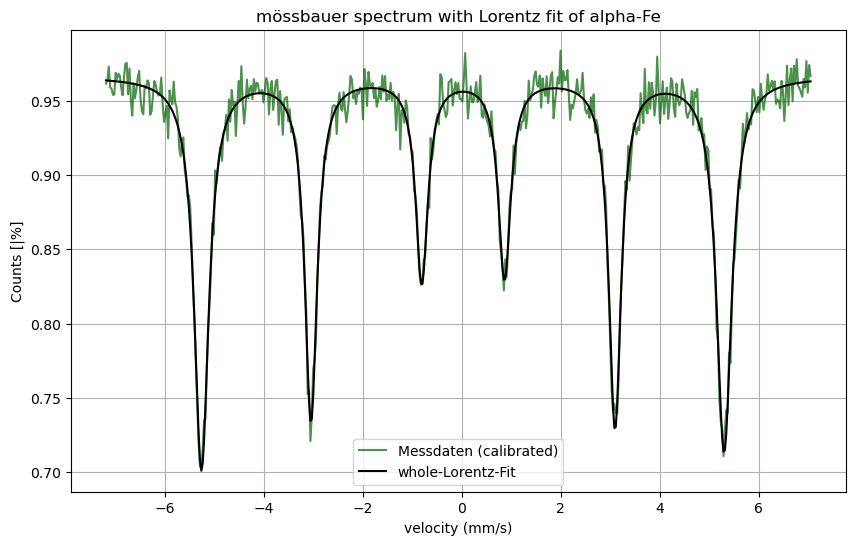

In [7]:
# lorentzian fit function
def lorentz(v, A, v0, gamma):
    # A: area, v0: Peak-center, gamma: HWHM 
    return (A / np.pi) * (gamma / ((v - v0)**2 + gamma**2))

def mose_sextet(v, y0, 
                A1, v1, g1,
                A2, v2, g2,
                A3, v3, g3,
                A4, v4, g4,
                A5, v5, g5,
                A6, v6, g6):
    
    return (y0 
            + lorentz(v, A1, v1, g1)
            + lorentz(v, A2, v2, g2)
            + lorentz(v, A3, v3, g3)
            + lorentz(v, A4, v4, g4)
            + lorentz(v, A5, v5, g5)
            + lorentz(v, A6, v6, g6))

y0_guess = 0.96         
gamma_guess = 0.15       
amp_guess = -0.1         

initial_guesses = [
    y0_guess,
    amp_guess, -5.3, gamma_guess,  # Peak 1 (-5.3 mm/s)
    amp_guess, -3.1, gamma_guess,    # Peak 2 (-3.1 mm/s)
    amp_guess, -0.8, gamma_guess,  # Peak 3 (-0.8 mm/s)
    amp_guess,  0.9, gamma_guess,    # Peak 4 (+0.9 mm/s)
    amp_guess,  3.1, gamma_guess,  # Peak 5 (+3.1 mm/s)
    amp_guess,  5.3, gamma_guess   # Peak 6 (+5.3 mm/s)
]

popt, pcov = curve_fit(mose_sextet, velocity, y_short, p0=initial_guesses)


# read fit
y0_fit = popt[0]
perr = np.sqrt(np.diag(pcov)) 

print(f"optionized undergrund y0: {y0_fit:.2f} ± {perr[0]:.2f}")
for i in range(6):
    idx = 1 + i * 3
    print(f"Peak {i+1}: Zentrum = {popt[idx+1]:.3f} ± {perr[idx+1]:.3f} mm/s, "
          f"Breite (FWHM) = {2*popt[idx+2]:.3f} mm/s")

#plot
plt.figure(figsize=(10, 6))

plt.plot(velocity, y_short, label='Messdaten (calibrated)', color='darkgreen', alpha=0.7)
plt.plot(velocity, mose_sextet(velocity, *popt),  label='whole-Lorentz-Fit', color='black')


plt.xlabel('velocity (mm/s)')
plt.ylabel('Counts [|%]')
plt.title('mössbauer spectrum with Lorentz fit of alpha-Fe')
plt.legend()
plt.grid(True)
plt.show()
